Optimal k: 14
Test Accuracy: 0.9556
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      1.00      0.94        15
   virginica       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



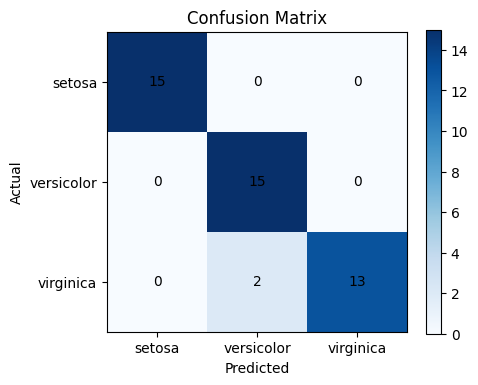

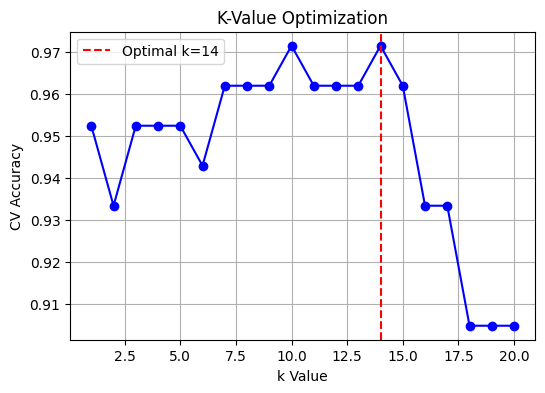

In [8]:
# Simple KNN Classification on Iris Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load and prepare data
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Find optimal k
k_range = range(1, 21)
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_scaled, y_train, cv=5).mean() for k in k_range]
optimal_k = k_range[np.argmax(cv_scores)]

# Train and evaluate KNN
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
print(f"Optimal k: {optimal_k}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.xticks(np.arange(len(iris.target_names)), iris.target_names)
plt.yticks(np.arange(len(iris.target_names)), iris.target_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

# k-value optimization curve
plt.figure(figsize=(6,4))
plt.plot(k_range, cv_scores, 'bo-')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
plt.xlabel('k Value')
plt.ylabel('CV Accuracy')
plt.title('K-Value Optimization')
plt.legend()
plt.grid(True)
plt.show()


Optimal k: 7
Test Accuracy: 0.7687

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.83      0.82       165
           1       0.71      0.67      0.69       103

    accuracy                           0.77       268
   macro avg       0.76      0.75      0.75       268
weighted avg       0.77      0.77      0.77       268



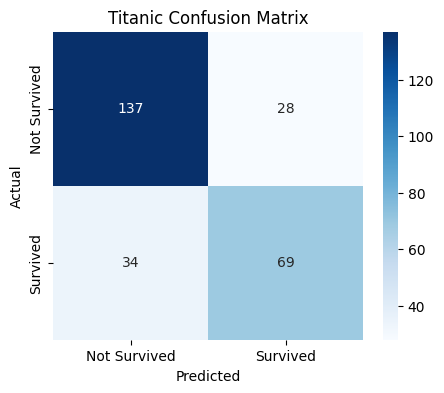

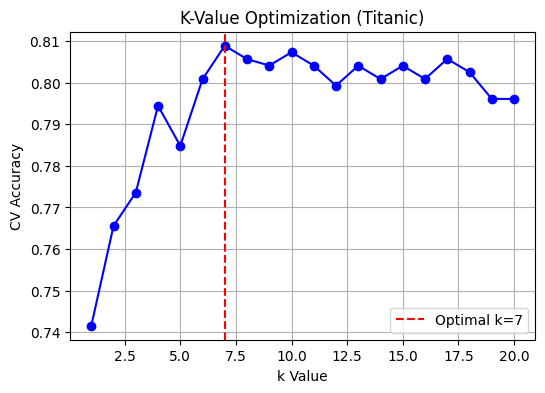

In [6]:
# Simple KNN Classification on Titanic Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# Load Titanic Dataset
# -----------------------------
df = sns.load_dataset('titanic')

# -----------------------------
# Basic preprocessing
# -----------------------------
df = df.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'], axis=1)

# Fill missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['alone'].fillna(df['alone'].mode()[0], inplace=True)

# Encode categorical variables
le = LabelEncoder()
for col in ['sex', 'embarked', 'alone']:
    df[col] = le.fit_transform(df[col])

# -----------------------------
# Features & Target
# -----------------------------
X = df.drop('survived', axis=1)
y = df['survived']

feature_names = X.columns

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -----------------------------
# Scaling (VERY important for KNN)
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Find optimal k
# -----------------------------
k_range = range(1, 21)

cv_scores = [
    cross_val_score(
        KNeighborsClassifier(n_neighbors=k),
        X_train_scaled,
        y_train,
        cv=5
    ).mean()
    for k in k_range
]

optimal_k = k_range[np.argmax(cv_scores)]

# -----------------------------
# Train final model
# -----------------------------
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

# -----------------------------
# Evaluation
# -----------------------------
print(f"Optimal k: {optimal_k}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])

plt.title('Titanic Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# -----------------------------
# k-value optimization curve
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(k_range, cv_scores, 'bo-')
plt.axvline(x=optimal_k, color='red', linestyle='--',
            label=f'Optimal k={optimal_k}')
plt.xlabel('k Value')
plt.ylabel('CV Accuracy')
plt.title('K-Value Optimization (Titanic)')
plt.legend()
plt.grid(True)
plt.show()

Optimal k: 11
Test Accuracy: 0.8060

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.92      0.85       165
           1       0.83      0.62      0.71       103

    accuracy                           0.81       268
   macro avg       0.81      0.77      0.78       268
weighted avg       0.81      0.81      0.80       268



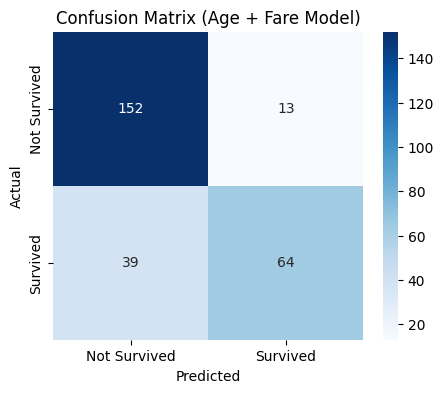

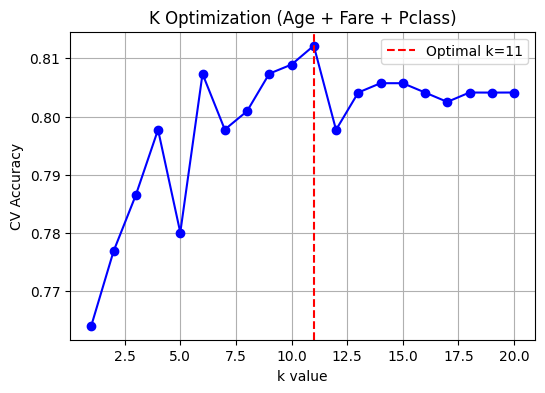

In [9]:
# KNN on Titanic (Using Age, Fare + key features only)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# Load dataset
# -----------------------------
df = sns.load_dataset('titanic')

# -----------------------------
# Select only useful features
# -----------------------------
df = df[['survived', 'age', 'fare', 'pclass', 'sex', 'embarked']]

# -----------------------------
# Handle missing values
# -----------------------------
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# -----------------------------
# Encode categorical features
# -----------------------------
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

# -----------------------------
# Features and target
# -----------------------------
X = df.drop('survived', axis=1)
y = df['survived']

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -----------------------------
# Scaling (VERY important for KNN)
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Find best k
# -----------------------------
k_range = range(1, 21)

cv_scores = [
    cross_val_score(
        KNeighborsClassifier(n_neighbors=k),
        X_train_scaled,
        y_train,
        cv=5
    ).mean()
    for k in k_range
]

optimal_k = k_range[np.argmax(cv_scores)]

# -----------------------------
# Train model
# -----------------------------
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

# -----------------------------
# Evaluation
# -----------------------------
print(f"Optimal k: {optimal_k}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])

plt.title('Confusion Matrix (Age + Fare Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# -----------------------------
# k optimization curve
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(k_range, cv_scores, 'bo-')
plt.axvline(optimal_k, color='red', linestyle='--',
            label=f'Optimal k={optimal_k}')
plt.xlabel('k value')
plt.ylabel('CV Accuracy')
plt.title('K Optimization (Age + Fare + Pclass)')
plt.legend()
plt.grid()
plt.show()

Optimal k: 11
Test Accuracy: 0.8060

Classification Report:

              precision    recall  f1-score   support

Not Survived       0.80      0.92      0.85       165
    Survived       0.83      0.62      0.71       103

    accuracy                           0.81       268
   macro avg       0.81      0.77      0.78       268
weighted avg       0.81      0.81      0.80       268



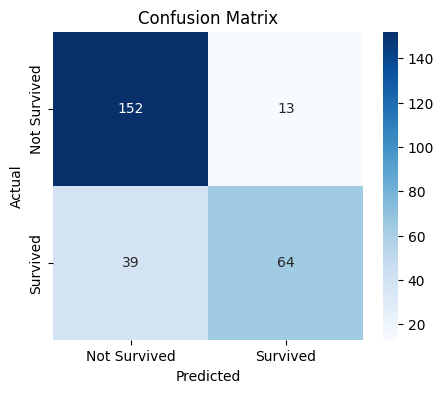

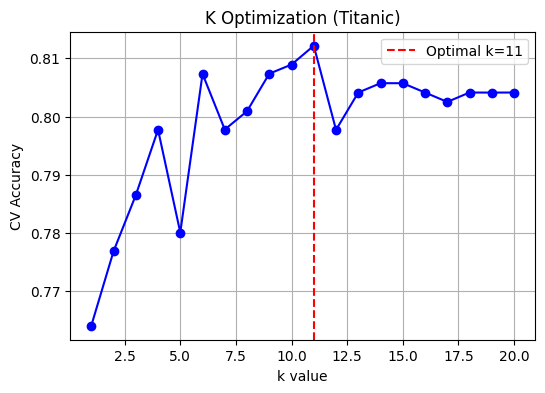

In [10]:
# KNN on Titanic with clear labels + pclass included

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# Load dataset
# -----------------------------
df = sns.load_dataset('titanic')

# -----------------------------
# Select important features (INCLUDING pclass)
# -----------------------------
df = df[['survived', 'age', 'fare', 'pclass', 'sex', 'embarked']]

# -----------------------------
# Handle missing values
# -----------------------------
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# -----------------------------
# Encode categorical variables
# -----------------------------
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

# -----------------------------
# Features and target
# -----------------------------
X = df.drop('survived', axis=1)
y = df['survived']

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -----------------------------
# Scaling (important for KNN)
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Find optimal k
# -----------------------------
k_range = range(1, 21)

cv_scores = [
    cross_val_score(
        KNeighborsClassifier(n_neighbors=k),
        X_train_scaled,
        y_train,
        cv=5
    ).mean()
    for k in k_range
]

optimal_k = k_range[np.argmax(cv_scores)]

# -----------------------------
# Train model
# -----------------------------
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

# -----------------------------
# Evaluation
# -----------------------------
print(f"Optimal k: {optimal_k}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Survived", "Survived"]
))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# -----------------------------
# K optimization curve
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(k_range, cv_scores, 'bo-')
plt.axvline(optimal_k, color='red', linestyle='--',
            label=f'Optimal k={optimal_k}')
plt.xlabel('k value')
plt.ylabel('CV Accuracy')
plt.title('K Optimization (Titanic)')
plt.legend()
plt.grid()
plt.show()